2026-01-19 05:26:45.209425: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-19 05:26:45.209736: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-19 05:26:45.260775: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-19 05:26:46.348030: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur


[1] Carregando dataset do CSV...
Dataset carregado: 10000 amostras, 14 colunas

Primeiras linhas do dataset:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88 

E0000 00:00:1768811213.649882   10516 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1768811213.656314   10516 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)


[5] Treinando o modelo...

[6] Avaliando modelo...

Acurácia no teste: 0.8585
AUC no teste: 0.8382

[7] Gerando visualizações...


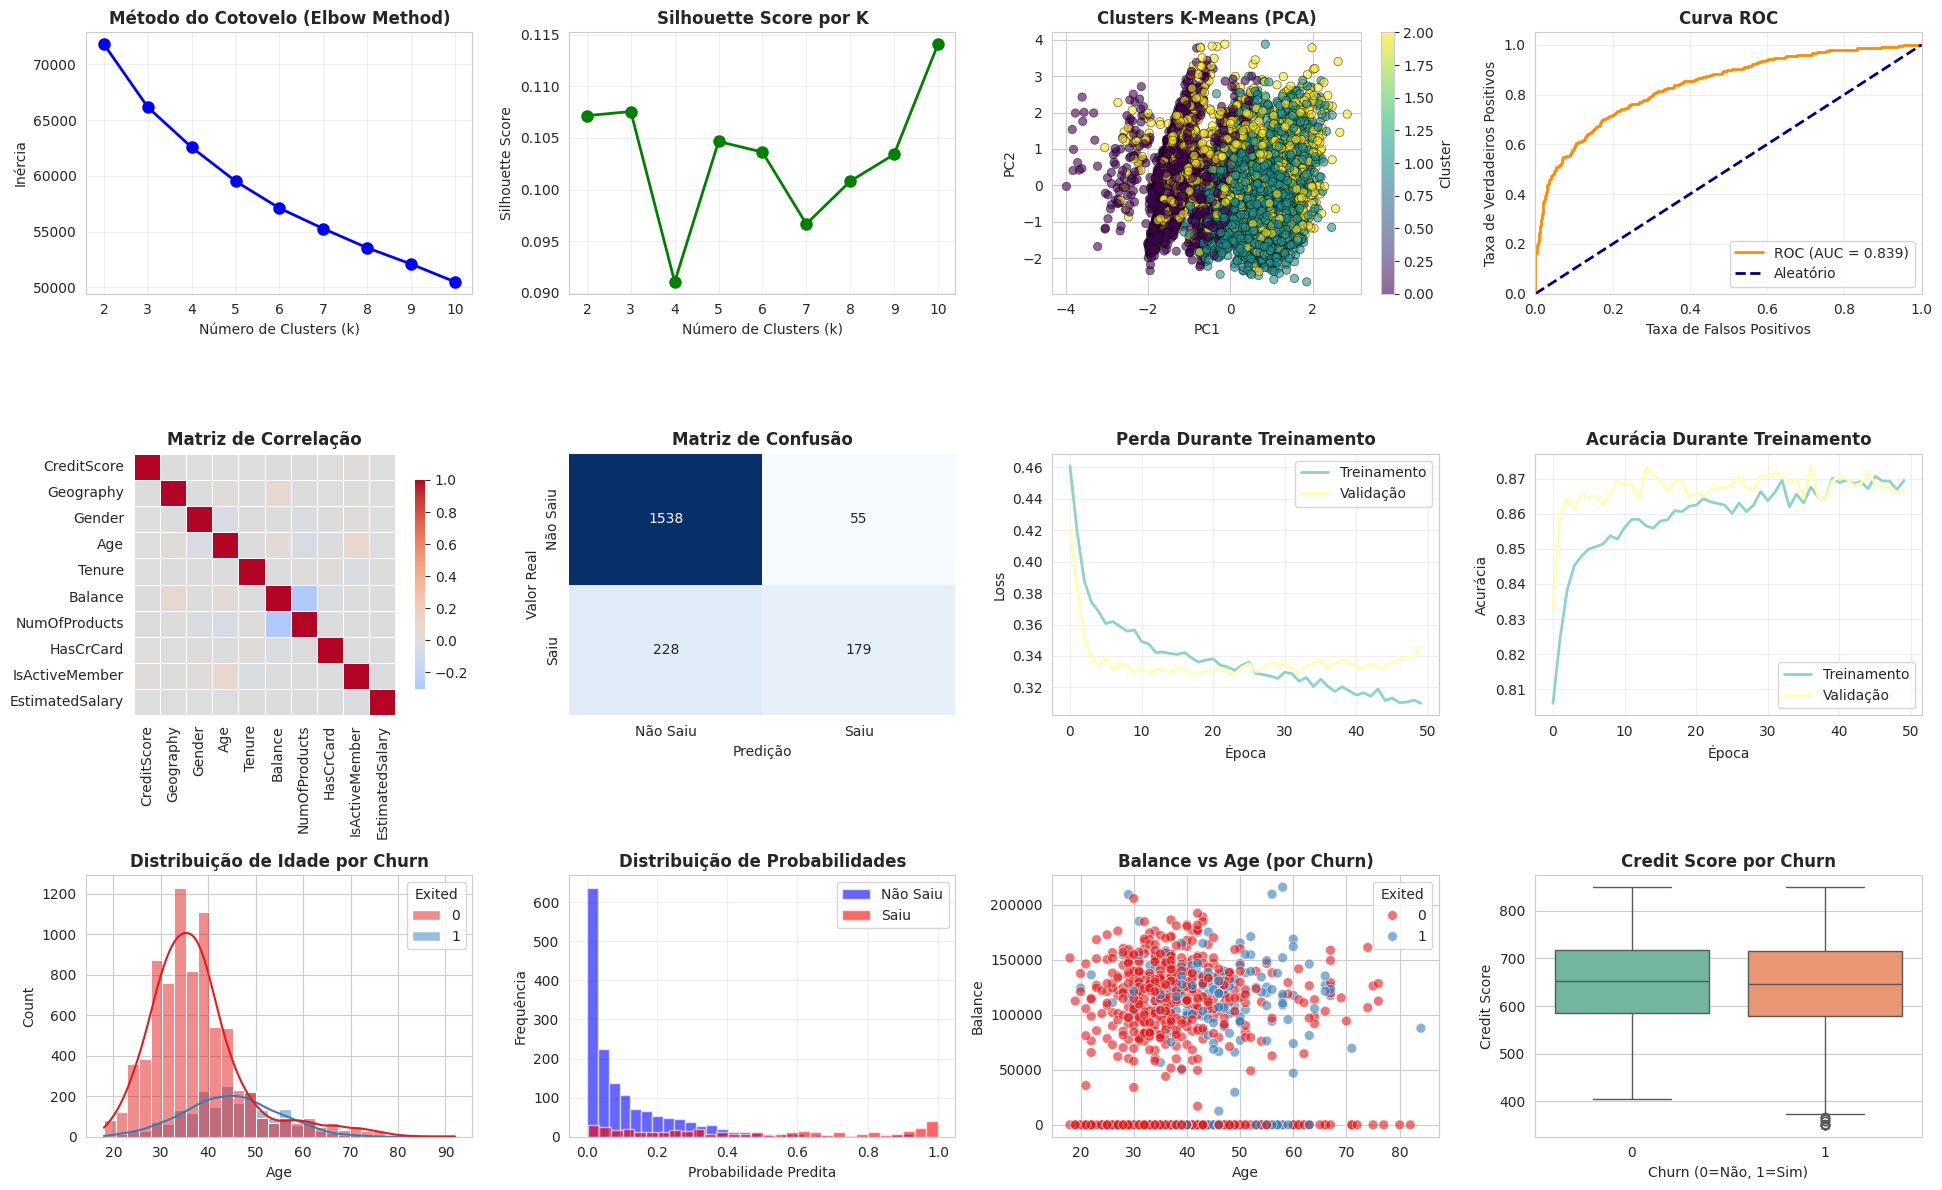


RELATÓRIO FINAL - ANÁLISE DE CHURN

📊 K-Means Clustering:
   - Clusters utilizados: 3
   - Silhouette Score: 0.1076

🧠 Deep Learning (Rede Neural):
   - Arquitetura: 10 → 128 → 64 → 32 → 1
   - Acurácia Final: 0.8585
   - AUC-ROC: 0.8385

📈 Curva ROC:
   - AUC Score: 0.8385
   - Interpretação: Bom

📋 Classification Report:
              precision    recall  f1-score   support

    Não Saiu       0.87      0.97      0.92      1593
        Saiu       0.76      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000


✅ Análise completa finalizada!
   Gráfico salvo como 'churn_analysis_complete.png'


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, silhouette_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 1. CARREGANDO DADOS DO CSV
print("\n[1] Carregando dataset do CSV...")
df = pd.read_csv('/home/marcello/Documentos/Churn_Modelling.csv')

print(f"Dataset carregado: {df.shape[0]} amostras, {df.shape[1]} colunas")
print(f"\nPrimeiras linhas do dataset:")
print(df.head())
print(f"\nInformações do dataset:")
print(df.info())

# 2. PRÉ-PROCESSAMENTO
print("\n[2] Preparando dados...")

# Remover colunas não necessárias
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Codificar variáveis categóricas
le_geography = LabelEncoder()
le_gender = LabelEncoder()
df_processed['Geography'] = le_geography.fit_transform(df_processed['Geography'])
df_processed['Gender'] = le_gender.fit_transform(df_processed['Gender'])

print(f"\nDistribuição de Churn (Exited): {df_processed['Exited'].value_counts().to_dict()}")

# Separar features e target
X = df_processed.drop('Exited', axis=1).values
y = df_processed['Exited'].values
feature_names = df_processed.drop('Exited', axis=1).columns.tolist()

print(f"Features utilizadas: {feature_names}")

# Split de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. KMEANS CLUSTERING
print("\n[3] Aplicando K-Means Clustering...")
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Melhor número de clusters
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_train_scaled)
print(f"K-Means aplicado com {best_k} clusters")

# 4. DEEP LEARNING COM TENSORFLOW
print("\n[4] Construindo Rede Neural com TensorFlow...")

# Arquitetura da rede neural
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("\nArquitetura da Rede Neural:")
model.summary()

# Treinamento
print("\n[5] Treinando o modelo...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# 5. AVALIAÇÃO E PREDIÇÕES
print("\n[6] Avaliando modelo...")
y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Métricas
test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nAcurácia no teste: {test_acc:.4f}")
print(f"AUC no teste: {test_auc:.4f}")

# 6. CURVA ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 7. VISUALIZAÇÕES
print("\n[7] Gerando visualizações...")

fig = plt.figure(figsize=(20, 12))

# Subplot 1: Elbow Method para K-Means
ax1 = plt.subplot(3, 4, 1)
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=10)
plt.ylabel('Inércia', fontsize=10)
plt.title('Método do Cotovelo (Elbow Method)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 2: Silhouette Score
ax2 = plt.subplot(3, 4, 2)
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=10)
plt.ylabel('Silhouette Score', fontsize=10)
plt.title('Silhouette Score por K', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 3: Distribuição dos Clusters
ax3 = plt.subplot(3, 4, 3)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)
plt.title('Clusters K-Means (PCA)', fontsize=12, fontweight='bold')

# Subplot 4: Curva ROC
ax4 = plt.subplot(3, 4, 4)
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=10)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=10)
plt.title('Curva ROC', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 5: Matriz de Correlação (Heatmap Seaborn)
ax5 = plt.subplot(3, 4, 5)
corr_matrix = df_processed[feature_names].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação', fontsize=12, fontweight='bold')

# Subplot 6: Confusion Matrix
ax6 = plt.subplot(3, 4, 6)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Saiu', 'Saiu'],
            yticklabels=['Não Saiu', 'Saiu'])
plt.ylabel('Valor Real', fontsize=10)
plt.xlabel('Predição', fontsize=10)
plt.title('Matriz de Confusão', fontsize=12, fontweight='bold')

# Subplot 7: História do Treinamento - Loss
ax7 = plt.subplot(3, 4, 7)
plt.plot(history.history['loss'], label='Treinamento', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação', linewidth=2)
plt.xlabel('Época', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.title('Perda Durante Treinamento', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 8: História do Treinamento - Accuracy
ax8 = plt.subplot(3, 4, 8)
plt.plot(history.history['accuracy'], label='Treinamento', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validação', linewidth=2)
plt.xlabel('Época', fontsize=10)
plt.ylabel('Acurácia', fontsize=10)
plt.title('Acurácia Durante Treinamento', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 9: Distribuição de Idade por Churn
ax9 = plt.subplot(3, 4, 9)
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette='Set1')
plt.title('Distribuição de Idade por Churn', fontsize=12, fontweight='bold')

# Subplot 10: Distribuição de Probabilidades
ax10 = plt.subplot(3, 4, 10)
plt.hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, label='Não Saiu', color='blue')
plt.hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, label='Saiu', color='red')
plt.xlabel('Probabilidade Predita', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.title('Distribuição de Probabilidades', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 11: Balance vs Age com Churn
ax11 = plt.subplot(3, 4, 11)
sample_df = df.sample(min(1000, len(df)))
sns.scatterplot(data=sample_df, x='Age', y='Balance', hue='Exited',
                palette='Set1', s=50, alpha=0.6)
plt.title('Balance vs Age (por Churn)', fontsize=12, fontweight='bold')

# Subplot 12: Box Plot do CreditScore por Churn
ax12 = plt.subplot(3, 4, 12)
sns.boxplot(data=df, x='Exited', y='CreditScore', palette='Set2')
plt.xlabel('Churn (0=Não, 1=Sim)', fontsize=10)
plt.ylabel('Credit Score', fontsize=10)
plt.title('Credit Score por Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_analysis_complete.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. RELATÓRIO FINAL
print("\n" + "="*60)
print("RELATÓRIO FINAL - ANÁLISE DE CHURN")
print("="*60)
print(f"\n📊 K-Means Clustering:")
print(f"   - Clusters utilizados: {best_k}")
print(f"   - Silhouette Score: {silhouette_scores[best_k-2]:.4f}")

print(f"\n🧠 Deep Learning (Rede Neural):")
print(f"   - Arquitetura: {X_train_scaled.shape[1]} → 128 → 64 → 32 → 1")
print(f"   - Acurácia Final: {test_acc:.4f}")
print(f"   - AUC-ROC: {roc_auc:.4f}")

print(f"\n📈 Curva ROC:")
print(f"   - AUC Score: {roc_auc:.4f}")
print(f"   - Interpretação: {'Excelente' if roc_auc > 0.9 else 'Bom' if roc_auc > 0.8 else 'Razoável'}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Não Saiu', 'Saiu']))

print("\n✅ Análise completa finalizada!")
print("   Gráfico salvo como 'churn_analysis_complete.png'")
print("="*60)